In [1]:
import msprime
import numpy as np


def simulate_snp_matrix(
    n_samples=20,
    alpha=0.0,
    theta=10.0,
    rho=10.0,
    sequence_length=10_000,
    Ne=10_000,
    random_seed=None,
):
    """
    Simulate one SNP matrix under a single-population exponential growth model.

    Parameters
    ----------
    n_samples : int
        Number of haploid samples. If you want diploid individuals, see note below.
    alpha : float
        Population exponential growth rate.
    theta : float
        Population-scaled mutation parameter. We convert it to a per-base mutation rate.
    rho : float
        Population-scaled recombination parameter. We convert it to a per-base recombination rate.
    sequence_length : int
        Length of simulated region.
    Ne : int
        Effective population size used for scaling.
    random_seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    snp_matrix : np.ndarray
        Array of shape (n_samples, num_snps), entries 0/1.
    positions : np.ndarray
        Genomic positions of segregating sites.
    metadata : dict
        Dictionary containing simulation parameters and summary info.
    """

    # Convert population-scaled parameters to per-base rates.
    # Using the common coalescent scaling:
    # theta = 4 * Ne * mu * L
    # rho   = 4 * Ne * r  * L
    mu = theta / (4 * Ne * sequence_length)
    recomb_rate = rho / (4 * Ne * sequence_length)

    # Define a one-population demographic model with exponential growth
    demography = msprime.Demography()
    demography.add_population(
        name="pop",
        initial_size=Ne,
        growth_rate=alpha,
    )

    # Simulate ancestry
    ts_ancestry = msprime.sim_ancestry(
        samples=n_samples,
        demography=demography,
        sequence_length=sequence_length,
        recombination_rate=recomb_rate,
        random_seed=random_seed,
        ploidy=1,   # haploid samples for simpler SNP matrix handling
    )

    # Add binary mutations so genotype entries are 0/1
    ts_mut = msprime.sim_mutations(
        ts_ancestry,
        rate=mu,
        model=msprime.BinaryMutationModel(),
        random_seed=None if random_seed is None else random_seed + 1,
    )

    # Genotype matrix has shape (num_sites, num_samples), so transpose it
    G = ts_mut.genotype_matrix().T.astype(np.int8)

    # Site positions
    positions = np.array([site.position for site in ts_mut.sites()])

    metadata = {
        "n_samples": n_samples,
        "alpha": alpha,
        "theta": theta,
        "rho": rho,
        "sequence_length": sequence_length,
        "Ne": Ne,
        "mutation_rate": mu,
        "recombination_rate": recomb_rate,
        "num_snps": G.shape[1],
    }

    return G, positions, metadata

In [2]:
G, positions, meta = simulate_snp_matrix(
    n_samples=20,
    alpha=0.01,
    theta=20.0,
    rho=10.0,
    sequence_length=50_000,
    Ne=10_000,
    random_seed=42,
)

print("SNP matrix shape:", G.shape)
print("First 10 positions:", positions[:10])
print("Metadata:", meta)
print(G[:5, :10])  # first 5 samples, first 10 SNPs

SNP matrix shape: (20, 1)
First 10 positions: [19268.]
Metadata: {'n_samples': 20, 'alpha': 0.01, 'theta': 20.0, 'rho': 10.0, 'sequence_length': 50000, 'Ne': 10000, 'mutation_rate': 1e-08, 'recombination_rate': 5e-09, 'num_snps': 1}
[[0]
 [0]
 [1]
 [0]
 [0]]


In [3]:
import numpy as np
from tqdm import tqdm


def simulate_dataset(
    num_replicates=1000,
    n_choices=(20, 50, 100),
    alpha_range=(0.0, 0.05),
    theta_range=(5.0, 50.0),
    rho=10.0,
    sequence_length=50_000,
    Ne=10_000,
    seed=12345,
):
    """
    Generate many SNP matrices and their labels for supervised learning.

    Returns
    -------
    dataset : list of dict
        Each entry contains:
        - 'X': SNP matrix
        - 'positions': SNP positions
        - 'alpha': target label
        - 'theta'
        - 'n_samples'
        - 'metadata'
    """
    rng = np.random.default_rng(seed)
    dataset = []

    for i in tqdm(range(num_replicates)):
        n_samples = int(rng.choice(n_choices))
        alpha = float(rng.uniform(*alpha_range))
        theta = float(rng.uniform(*theta_range))
        sim_seed = int(rng.integers(1, 2**31 - 1))

        G, positions, meta = simulate_snp_matrix(
            n_samples=n_samples,
            alpha=alpha,
            theta=theta,
            rho=rho,
            sequence_length=sequence_length,
            Ne=Ne,
            random_seed=sim_seed,
        )

        dataset.append({
            "X": G,
            "positions": positions,
            "alpha": alpha,
            "theta": theta,
            "n_samples": n_samples,
            "metadata": meta,
        })

    return dataset

In [4]:
dataset = simulate_dataset(
    num_replicates=10,
    n_choices=(20, 50),
    alpha_range=(0.0, 0.05),
    theta_range=(5.0, 20.0),
    rho=10.0,
    sequence_length=20_000,
    Ne=10_000,
    seed=1,
)

print("Number of replicates:", len(dataset))
print("Example keys:", dataset[0].keys())
print("Example SNP matrix shape:", dataset[0]["X"].shape)
print("Example alpha:", dataset[0]["alpha"])

100%|██████████| 10/10 [00:00<00:00, 187.96it/s]

Number of replicates: 10
Example keys: dict_keys(['X', 'positions', 'alpha', 'theta', 'n_samples', 'metadata'])
Example SNP matrix shape: (20, 1)
Example alpha: 0.04752318481629677


In [5]:
import numpy as np
from tqdm import tqdm


def simulate_dataset(
    num_replicates=1000,
    n_choices=(20, 50, 100),
    alpha_range=(0.0, 0.05),
    theta_range=(5.0, 50.0),
    rho=10.0,
    sequence_length=50_000,
    Ne=10_000,
    seed=12345,
):
    """
    Generate many SNP matrices and their labels for supervised learning.

    Returns
    -------
    dataset : list of dict
        Each entry contains:
        - 'X': SNP matrix
        - 'positions': SNP positions
        - 'alpha': target label
        - 'theta'
        - 'n_samples'
        - 'metadata'
    """
    rng = np.random.default_rng(seed)
    dataset = []

    for i in tqdm(range(num_replicates)):
        n_samples = int(rng.choice(n_choices))
        alpha = float(rng.uniform(*alpha_range))
        theta = float(rng.uniform(*theta_range))
        sim_seed = int(rng.integers(1, 2**31 - 1))

        G, positions, meta = simulate_snp_matrix(
            n_samples=n_samples,
            alpha=alpha,
            theta=theta,
            rho=rho,
            sequence_length=sequence_length,
            Ne=Ne,
            random_seed=sim_seed,
        )

        dataset.append({
            "X": G,
            "positions": positions,
            "alpha": alpha,
            "theta": theta,
            "n_samples": n_samples,
            "metadata": meta,
        })

    return dataset

In [11]:
dataset = simulate_dataset(
    num_replicates=20000,
    n_choices=(20, 50),
    alpha_range=(0.0, 0.05),
    theta_range=(5.0, 20.0),
    rho=10.0,
    sequence_length=20_000,
    Ne=10_000,
    seed=1,
)

print("Number of replicates:", len(dataset))
print("Example keys:", dataset[0].keys())
print("Example SNP matrix shape:", dataset[0]["X"].shape)
print("Example alpha:", dataset[0]["alpha"])

100%|██████████| 20000/20000 [01:32<00:00, 215.10it/s]

Number of replicates: 20000
Example keys: dict_keys(['X', 'positions', 'alpha', 'theta', 'n_samples', 'metadata'])
Example SNP matrix shape: (20, 1)
Example alpha: 0.04752318481629677


In [12]:
import pickle

with open("simulated_snp_dataset.pkl", "wb") as f:
    pickle.dump(dataset, f)

In [13]:
with open("simulated_snp_dataset.pkl", "rb") as f:
    dataset = pickle.load(f)

In [14]:
len(dataset)

20000

In [17]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [18]:
with open("simulated_snp_dataset.pkl", "rb") as f:
    dataset = pickle.load(f)

print("Number of simulations:", len(dataset))
print("Example keys:", dataset[0].keys())
print("Example matrix shape:", dataset[0]["X"].shape)
print("Example alpha:", dataset[0]["alpha"])

Number of simulations: 20000
Example keys: dict_keys(['X', 'positions', 'alpha', 'theta', 'n_samples', 'metadata'])
Example matrix shape: (20, 1)
Example alpha: 0.04752318481629677


In [19]:
def extract_features(item):
    """
    Convert one simulated SNP dataset item into a fixed-length feature vector.
    
    item should contain:
      - item["X"]: SNP matrix of shape (n_samples, num_snps)
      - item["theta"]
      - item["metadata"]
    """
    G = item["X"]   # shape: (n_samples, num_snps)
    n, s = G.shape
    
    theta = item.get("theta", np.nan)
    seq_len = item.get("metadata", {}).get("sequence_length", np.nan)
    
    # Handle edge case: zero SNPs
    if s == 0:
        return {
            "n_samples": n,
            "num_snps": 0,
            "snp_density": 0.0,
            "theta": theta,
            "sequence_length": seq_len,
            "mean_af": 0.0,
            "std_af": 0.0,
            "min_af": 0.0,
            "max_af": 0.0,
            "mean_heterozygosity": 0.0,
            "std_heterozygosity": 0.0,
            "singleton_prop": 0.0,
            "doubleton_prop": 0.0,
            "mean_minor_ac": 0.0,
            "var_minor_ac": 0.0,
            "mean_pairwise_diff": 0.0,
        }
    
    # Derived allele frequency per SNP
    allele_counts = G.sum(axis=0)                 # shape: (num_snps,)
    af = allele_counts / n                        # allele frequency
    minor_ac = np.minimum(allele_counts, n - allele_counts)
    
    # Per-site heterozygosity proxy
    heterozygosity = 2 * af * (1 - af)
    
    singleton_prop = np.mean((allele_counts == 1) | (allele_counts == n - 1))
    doubleton_prop = np.mean((allele_counts == 2) | (allele_counts == n - 2))
    
    # Mean pairwise difference proxy:
    # For a biallelic site, expected pairwise difference = 2p(1-p)
    mean_pairwise_diff = np.sum(heterozygosity)
    
    return {
        "n_samples": n,
        "num_snps": s,
        "snp_density": s / seq_len if seq_len and seq_len > 0 else np.nan,
        "theta": theta,
        "sequence_length": seq_len,
        "mean_af": np.mean(af),
        "std_af": np.std(af),
        "min_af": np.min(af),
        "max_af": np.max(af),
        "mean_heterozygosity": np.mean(heterozygosity),
        "std_heterozygosity": np.std(heterozygosity),
        "singleton_prop": singleton_prop,
        "doubleton_prop": doubleton_prop,
        "mean_minor_ac": np.mean(minor_ac),
        "var_minor_ac": np.var(minor_ac),
        "mean_pairwise_diff": mean_pairwise_diff,
    }

In [20]:
rows = []
targets = []

for item in dataset:
    rows.append(extract_features(item))
    targets.append(item["alpha"])

X_df = pd.DataFrame(rows)
y = np.array(targets)

print(X_df.head())
print("Feature matrix shape:", X_df.shape)
print("Target shape:", y.shape)

   n_samples  num_snps  snp_density      theta  sequence_length  mean_af  \
0         20         1      0.00005   7.162394            20000     0.05   
1         50         0      0.00000  11.349897            20000     0.00   
2         20         1      0.00005  13.243905            20000     0.25   
3         20         2      0.00010  13.072150            20000     0.05   
4         50         1      0.00005   9.547922            20000     0.04   

   std_af  min_af  max_af  mean_heterozygosity  std_heterozygosity  \
0     0.0    0.05    0.05               0.0950                 0.0   
1     0.0    0.00    0.00               0.0000                 0.0   
2     0.0    0.25    0.25               0.3750                 0.0   
3     0.0    0.05    0.05               0.0950                 0.0   
4     0.0    0.04    0.04               0.0768                 0.0   

   singleton_prop  doubleton_prop  mean_minor_ac  var_minor_ac  \
0             1.0             0.0            1.0        

In [21]:
print(X_df.isnull().sum())

n_samples              0
num_snps               0
snp_density            0
theta                  0
sequence_length        0
mean_af                0
std_af                 0
min_af                 0
max_af                 0
mean_heterozygosity    0
std_heterozygosity     0
singleton_prop         0
doubleton_prop         0
mean_minor_ac          0
var_minor_ac           0
mean_pairwise_diff     0
dtype: int64


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X_df, y, test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 16000
Test size: 4000


In [23]:
def evaluate_regression(model, X_train, X_test, y_train, y_test, name="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    corr = np.corrcoef(y_test, y_pred)[0, 1]
    
    print(f"\n{name}")
    print("-" * len(name))
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE : {mae:.6f}")
    print(f"R²  : {r2:.6f}")
    print(f"Pearson corr: {corr:.6f}")
    
    return y_pred, {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "PearsonCorr": corr
    }

In [24]:
ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge_pred, ridge_metrics = evaluate_regression(
    ridge_model, X_train, X_test, y_train, y_test, name="Ridge Regression"
)


Ridge Regression
----------------
RMSE: 0.012097
MAE : 0.010100
R²  : 0.293419
Pearson corr: 0.543331


In [25]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_pred, rf_metrics = evaluate_regression(
    rf_model, X_train, X_test, y_train, y_test, name="Random Forest"
)


Random Forest
-------------
RMSE: 0.011835
MAE : 0.009698
R²  : 0.323689
Pearson corr: 0.569331


In [27]:
results_df = pd.DataFrame([
    {"Model": "Ridge Regression", **ridge_metrics},
    {"Model": "Random Forest", **rf_metrics},
])

print(results_df)

              Model      RMSE       MAE        R2  PearsonCorr
0  Ridge Regression  0.012097  0.010100  0.293419     0.543331
1     Random Forest  0.011835  0.009698  0.323689     0.569331


In [28]:
def plot_true_vs_pred(y_true, y_pred, title):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.4)
    
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    
    plt.xlabel("True alpha")
    plt.ylabel("Predicted alpha")
    plt.title(title)
    plt.tight_layout()
    plt.show()

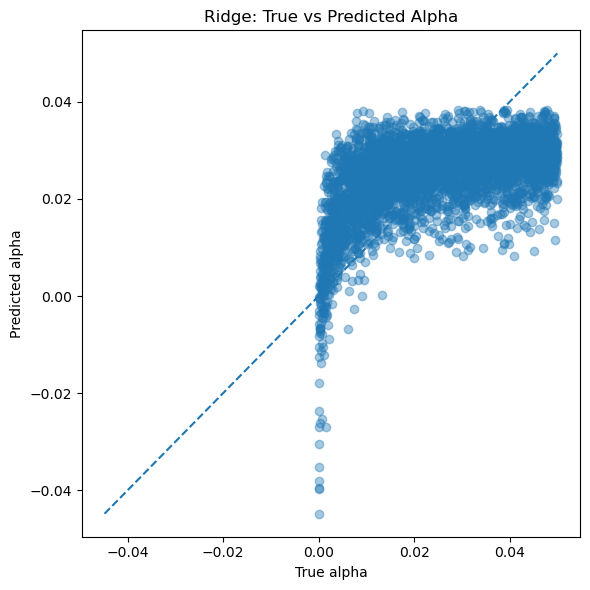

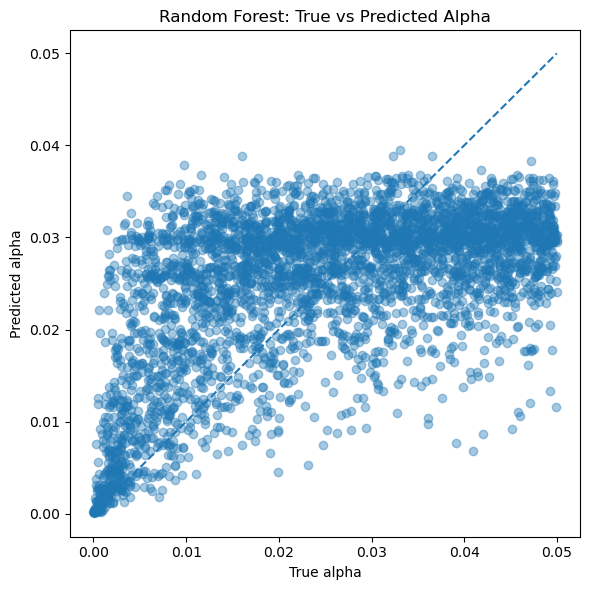

In [29]:
plot_true_vs_pred(y_test, ridge_pred, "Ridge: True vs Predicted Alpha")
plot_true_vs_pred(y_test, rf_pred, "Random Forest: True vs Predicted Alpha")

In [30]:
def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    
    plt.figure(figsize=(6, 4))
    plt.scatter(y_pred, residuals, alpha=0.4)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Predicted alpha")
    plt.ylabel("Residual (true - pred)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

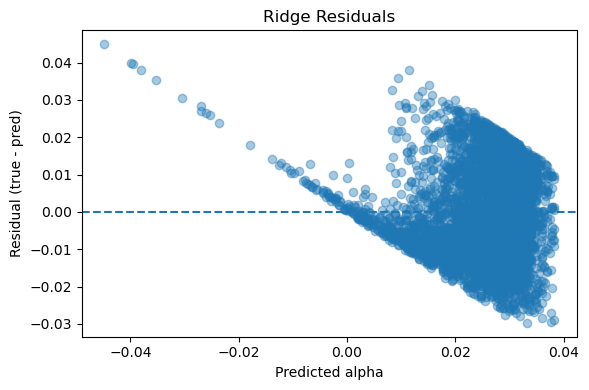

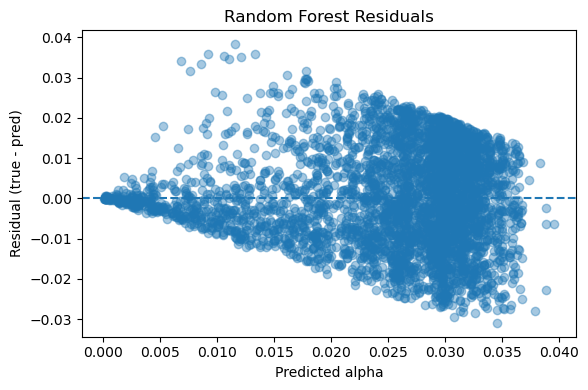

In [31]:
plot_residuals(y_test, ridge_pred, "Ridge Residuals")
plot_residuals(y_test, rf_pred, "Random Forest Residuals")

In [32]:
importances = rf_model.feature_importances_
feature_names = X_train.columns

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(imp_df.head(10))

                feature  importance
15   mean_pairwise_diff    0.276755
1              num_snps    0.226088
3                 theta    0.220217
2           snp_density    0.178182
13        mean_minor_ac    0.014182
9   mean_heterozygosity    0.013280
8                max_af    0.010513
6                std_af    0.010384
10   std_heterozygosity    0.010091
5               mean_af    0.009858


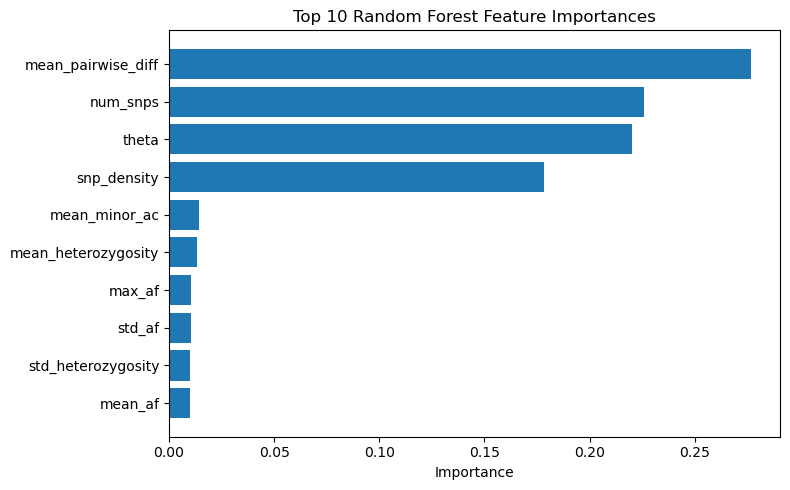

In [33]:
plt.figure(figsize=(8, 5))
plt.barh(imp_df["feature"].head(10)[::-1], imp_df["importance"].head(10)[::-1])
plt.xlabel("Importance")
plt.title("Top 10 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

In [34]:
test_results = X_test.copy()
test_results["true_alpha"] = y_test
test_results["rf_pred"] = rf_pred
test_results["ridge_pred"] = ridge_pred

for n_val in sorted(test_results["n_samples"].unique()):
    sub = test_results[test_results["n_samples"] == n_val]
    if len(sub) < 2:
        continue
    
    corr_rf = np.corrcoef(sub["true_alpha"], sub["rf_pred"])[0, 1]
    rmse_rf = np.sqrt(mean_squared_error(sub["true_alpha"], sub["rf_pred"]))
    
    print(f"n_samples = {n_val}")
    print(f"  RF corr = {corr_rf:.4f}, RF RMSE = {rmse_rf:.4f}")

n_samples = 20
  RF corr = 0.5441, RF RMSE = 0.0120
n_samples = 50
  RF corr = 0.5944, RF RMSE = 0.0116


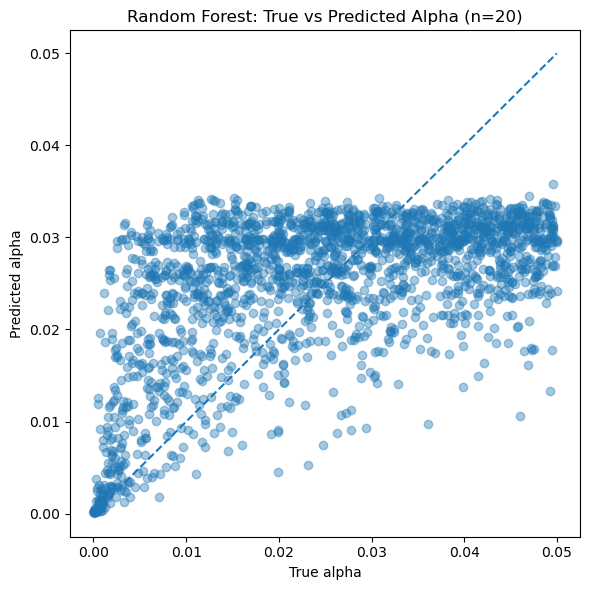

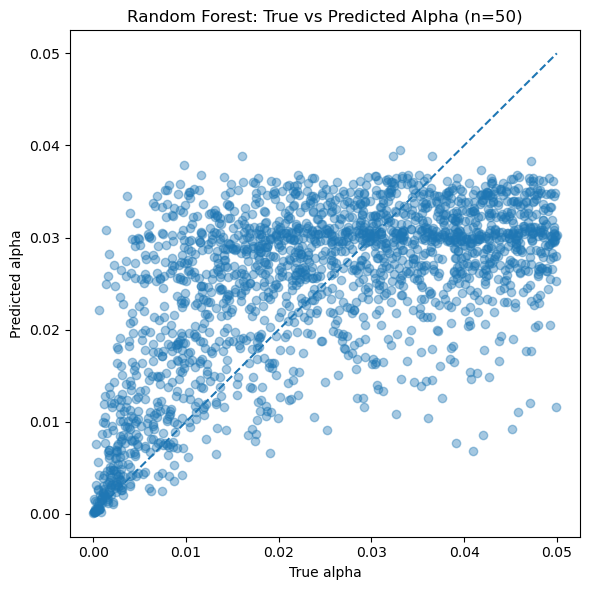

In [35]:
for n_val in sorted(test_results["n_samples"].unique()):
    sub = test_results[test_results["n_samples"] == n_val]
    plot_true_vs_pred(
        sub["true_alpha"].values,
        sub["rf_pred"].values,
        f"Random Forest: True vs Predicted Alpha (n={n_val})"
    )

In [36]:
import pickle
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

with open("simulated_snp_dataset.pkl", "rb") as f:
    dataset = pickle.load(f)

# Reuse your extract_features(item)
rows = [extract_features(item) for item in dataset]
X_df = pd.DataFrame(rows).fillna(0)
y = np.array([item["alpha"] for item in dataset], dtype=np.float32)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_df, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

(14450, 16) (2550, 16) (3000, 16)


In [37]:
import torch
from torch.utils.data import Dataset, DataLoader


class SummaryDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_ds = SummaryDataset(X_train_scaled, y_train)
val_ds = SummaryDataset(X_val_scaled, y_val)
test_ds = SummaryDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

In [38]:
import torch.nn as nn


class MLPRegressor(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

In [39]:
import copy
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def evaluate_model(model, loader, device):
    model.eval()
    ys, preds = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(X_batch)

            ys.append(y_batch.cpu().numpy())
            preds.append(pred.cpu().numpy())

    y_true = np.vstack(ys).ravel()
    y_pred = np.vstack(preds).ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1]

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "corr": corr,
        "y_true": y_true,
        "y_pred": y_pred
    }


def train_mlp(model, train_loader, val_loader, device, lr=1e-3, epochs=50):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_rmse = float("inf")
    best_state = None

    train_losses = []
    val_rmses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            pred = model(X_batch)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(X_batch)

        train_loss = running_loss / len(train_loader.dataset)
        val_metrics = evaluate_model(model, val_loader, device)

        train_losses.append(train_loss)
        val_rmses.append(val_metrics["rmse"])

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val RMSE: {val_metrics['rmse']:.6f} | "
            f"Val Corr: {val_metrics['corr']:.4f}"
        )

        if val_metrics["rmse"] < best_val_rmse:
            best_val_rmse = val_metrics["rmse"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return train_losses, val_rmses

In [42]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = MLPRegressor(input_dim=X_train_scaled.shape[1]).to(device)
train_losses, val_rmses = train_mlp(
    model, train_loader, val_loader, device, lr=1e-3, epochs=50
)

test_metrics = evaluate_model(model, test_loader, device)
print("\nMLP Test Performance")
print(test_metrics["rmse"], test_metrics["mae"], test_metrics["r2"], test_metrics["corr"])

cuda
Epoch 001 | Train Loss: 0.001583 | Val RMSE: 0.014235 | Val Corr: 0.2768
Epoch 002 | Train Loss: 0.000284 | Val RMSE: 0.012891 | Val Corr: 0.5023
Epoch 003 | Train Loss: 0.000206 | Val RMSE: 0.012536 | Val Corr: 0.5358
Epoch 004 | Train Loss: 0.000177 | Val RMSE: 0.012473 | Val Corr: 0.5435
Epoch 005 | Train Loss: 0.000168 | Val RMSE: 0.012317 | Val Corr: 0.5500
Epoch 006 | Train Loss: 0.000163 | Val RMSE: 0.012271 | Val Corr: 0.5525
Epoch 007 | Train Loss: 0.000161 | Val RMSE: 0.012296 | Val Corr: 0.5562
Epoch 008 | Train Loss: 0.000158 | Val RMSE: 0.012177 | Val Corr: 0.5602
Epoch 009 | Train Loss: 0.000153 | Val RMSE: 0.012221 | Val Corr: 0.5611
Epoch 010 | Train Loss: 0.000155 | Val RMSE: 0.012294 | Val Corr: 0.5636
Epoch 011 | Train Loss: 0.000155 | Val RMSE: 0.012074 | Val Corr: 0.5641
Epoch 012 | Train Loss: 0.000152 | Val RMSE: 0.012133 | Val Corr: 0.5647
Epoch 013 | Train Loss: 0.000151 | Val RMSE: 0.012123 | Val Corr: 0.5666
Epoch 014 | Train Loss: 0.000150 | Val RMSE: 0

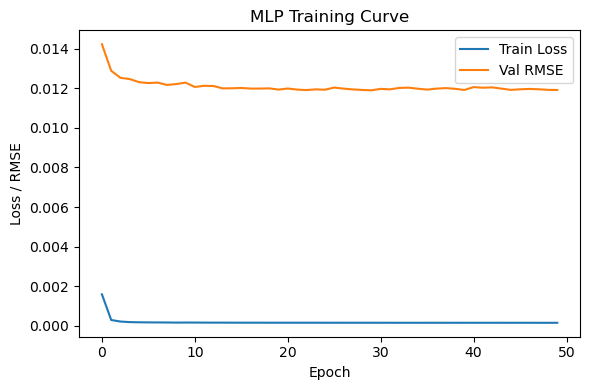

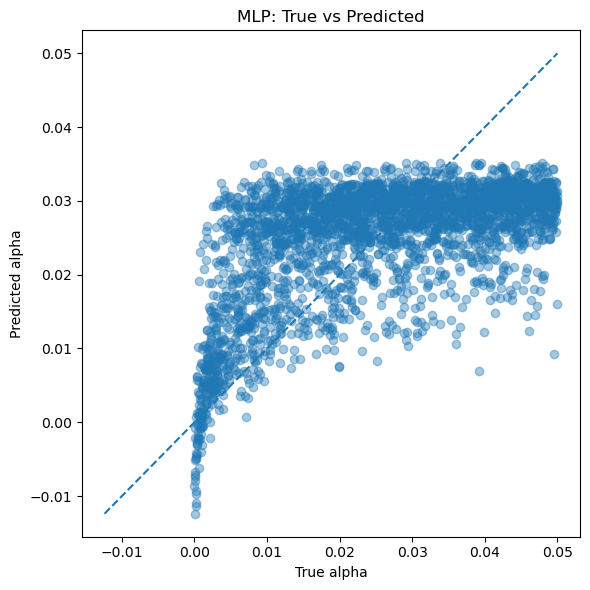

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_rmses, label="Val RMSE")
plt.xlabel("Epoch")
plt.ylabel("Loss / RMSE")
plt.title("MLP Training Curve")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(test_metrics["y_true"], test_metrics["y_pred"], alpha=0.4)
mn = min(test_metrics["y_true"].min(), test_metrics["y_pred"].min())
mx = max(test_metrics["y_true"].max(), test_metrics["y_pred"].max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("True alpha")
plt.ylabel("Predicted alpha")
plt.title("MLP: True vs Predicted")
plt.tight_layout()
plt.show()

## CNN

In [46]:
def pad_matrix(G, max_n_samples=50, max_snps=200):
    n, s = G.shape
    out = np.zeros((max_n_samples, max_snps), dtype=np.float32)

    n_use = min(n, max_n_samples)
    s_use = min(s, max_snps)

    out[:n_use, :s_use] = G[:n_use, :s_use]
    return out

In [47]:
num_snps_list = [item["X"].shape[1] for item in dataset]
print(np.percentile(num_snps_list, [50, 75, 90, 95, 99]))

[ 1.  2.  4.  6. 13.]


In [48]:
X_mats = np.stack([
    pad_matrix(item["X"], max_n_samples=50, max_snps=200)
    for item in dataset
])

y = np.array([item["alpha"] for item in dataset], dtype=np.float32)

# add channel dimension
X_mats = X_mats[:, None, :, :]   # shape: (N, 1, 50, 200)

print(X_mats.shape, y.shape)

(20000, 1, 50, 200) (20000,)


In [49]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_mats, y, test_size=0.15, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15, random_state=42
)

In [50]:
class MatrixDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_ds = MatrixDataset(X_train, y_train)
val_ds = MatrixDataset(X_val, y_val)
test_ds = MatrixDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

In [51]:
class SNPMatrixCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 6 * 25, 128),   # for input (1,50,200)
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x

In [52]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
cnn_model = SNPMatrixCNN().to(device)
train_losses, val_rmses = train_mlp(
    cnn_model, train_loader, val_loader, device, lr=1e-3, epochs=30
)

cnn_test_metrics = evaluate_model(cnn_model, test_loader, device)
print("\nCNN Test Performance")
print(cnn_test_metrics["rmse"], cnn_test_metrics["mae"], cnn_test_metrics["r2"], cnn_test_metrics["corr"])

Epoch 001 | Train Loss: 0.000353 | Val RMSE: 0.012590 | Val Corr: 0.5377
Epoch 002 | Train Loss: 0.000189 | Val RMSE: 0.012284 | Val Corr: 0.5425
Epoch 003 | Train Loss: 0.000165 | Val RMSE: 0.012254 | Val Corr: 0.5476
Epoch 004 | Train Loss: 0.000158 | Val RMSE: 0.012265 | Val Corr: 0.5413
Epoch 005 | Train Loss: 0.000152 | Val RMSE: 0.012557 | Val Corr: 0.5316
Epoch 006 | Train Loss: 0.000152 | Val RMSE: 0.012270 | Val Corr: 0.5432
Epoch 007 | Train Loss: 0.000151 | Val RMSE: 0.012445 | Val Corr: 0.5398
Epoch 008 | Train Loss: 0.000151 | Val RMSE: 0.012378 | Val Corr: 0.5439
Epoch 009 | Train Loss: 0.000150 | Val RMSE: 0.012412 | Val Corr: 0.5331
Epoch 010 | Train Loss: 0.000150 | Val RMSE: 0.012240 | Val Corr: 0.5456
Epoch 011 | Train Loss: 0.000149 | Val RMSE: 0.012413 | Val Corr: 0.5385
Epoch 012 | Train Loss: 0.000149 | Val RMSE: 0.012287 | Val Corr: 0.5478
Epoch 013 | Train Loss: 0.000150 | Val RMSE: 0.012370 | Val Corr: 0.5419
Epoch 014 | Train Loss: 0.000149 | Val RMSE: 0.0122

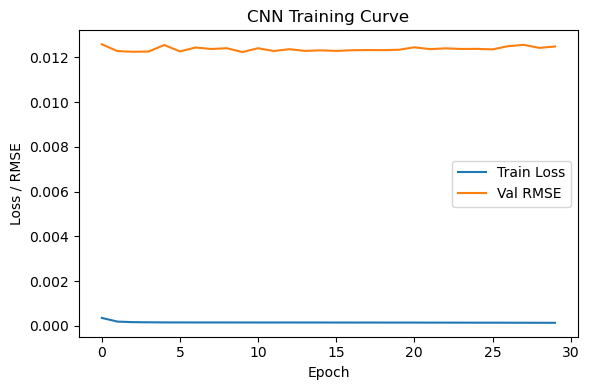

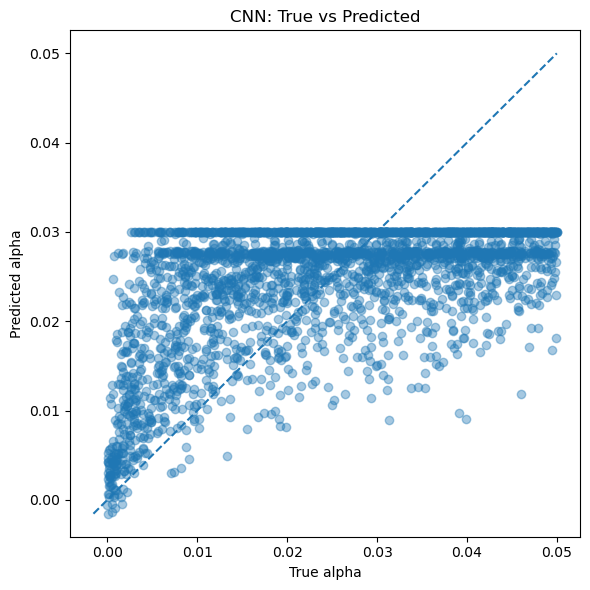

In [53]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_rmses, label="Val RMSE")
plt.xlabel("Epoch")
plt.ylabel("Loss / RMSE")
plt.title("CNN Training Curve")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(cnn_test_metrics["y_true"], cnn_test_metrics["y_pred"], alpha=0.4)
mn = min(cnn_test_metrics["y_true"].min(), cnn_test_metrics["y_pred"].min())
mx = max(cnn_test_metrics["y_true"].max(), cnn_test_metrics["y_pred"].max())
plt.plot([mn, mx], [mn, mx], linestyle="--")
plt.xlabel("True alpha")
plt.ylabel("Predicted alpha")
plt.title("CNN: True vs Predicted")
plt.tight_layout()
plt.show()

## Advanced Model

In [55]:
# matrix branch
X_mats = np.stack([
    pad_matrix(item["X"], max_n_samples=50, max_snps=200)
    for item in dataset
])[:, None, :, :]

# summary branch
rows = [extract_features(item) for item in dataset]
X_tab = pd.DataFrame(rows).fillna(0).values.astype(np.float32)

# scale tabular features
from sklearn.preprocessing import StandardScaler
tab_scaler = StandardScaler()
X_tab = tab_scaler.fit_transform(X_tab).astype(np.float32)

y = np.array([item["alpha"] for item in dataset], dtype=np.float32)

In [56]:
idx = np.arange(len(y))
idx_trainval, idx_test = train_test_split(idx, test_size=0.15, random_state=42)
idx_train, idx_val = train_test_split(idx_trainval, test_size=0.15, random_state=42)

Xmat_train, Xmat_val, Xmat_test = X_mats[idx_train], X_mats[idx_val], X_mats[idx_test]
Xtab_train, Xtab_val, Xtab_test = X_tab[idx_train], X_tab[idx_val], X_tab[idx_test]
y_train, y_val, y_test = y[idx_train], y[idx_val], y[idx_test]

In [57]:
class HybridDataset(Dataset):
    def __init__(self, Xmat, Xtab, y):
        self.Xmat = torch.tensor(Xmat, dtype=torch.float32)
        self.Xtab = torch.tensor(Xtab, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.Xmat[idx], self.Xtab[idx], self.y[idx]

In [58]:
class HybridSNPModel(nn.Module):
    def __init__(self, tab_dim):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.cnn_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 6 * 25, 128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.tab_head = nn.Sequential(
            nn.Linear(tab_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU()
        )

        self.final_head = nn.Sequential(
            nn.Linear(128 + 32, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 1)
        )

    def forward(self, xmat, xtab):
        a = self.cnn(xmat)
        a = self.cnn_head(a)

        b = self.tab_head(xtab)

        x = torch.cat([a, b], dim=1)
        return self.final_head(x)

In [59]:
def evaluate_hybrid(model, loader, device):
    model.eval()
    ys, preds = [], []

    with torch.no_grad():
        for xmat, xtab, y_batch in loader:
            xmat = xmat.to(device)
            xtab = xtab.to(device)
            y_batch = y_batch.to(device)

            pred = model(xmat, xtab)

            ys.append(y_batch.cpu().numpy())
            preds.append(pred.cpu().numpy())

    y_true = np.vstack(ys).ravel()
    y_pred = np.vstack(preds).ravel()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1]

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "corr": corr,
        "y_true": y_true,
        "y_pred": y_pred
    }


def train_hybrid(model, train_loader, val_loader, device, lr=1e-3, epochs=30):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_rmse = float("inf")
    best_state = None
    train_losses = []
    val_rmses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for xmat, xtab, y_batch in train_loader:
            xmat = xmat.to(device)
            xtab = xtab.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            pred = model(xmat, xtab)
            loss = criterion(pred, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(xmat)

        train_loss = running_loss / len(train_loader.dataset)
        val_metrics = evaluate_hybrid(model, val_loader, device)

        train_losses.append(train_loss)
        val_rmses.append(val_metrics["rmse"])

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val RMSE: {val_metrics['rmse']:.6f} | "
            f"Val Corr: {val_metrics['corr']:.4f}"
        )

        if val_metrics["rmse"] < best_val_rmse:
            best_val_rmse = val_metrics["rmse"]
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    return train_losses, val_rmses

In [60]:
train_ds = HybridDataset(Xmat_train, Xtab_train, y_train)
val_ds = HybridDataset(Xmat_val, Xtab_val, y_val)
test_ds = HybridDataset(Xmat_test, Xtab_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

hybrid_model = HybridSNPModel(tab_dim=Xtab_train.shape[1]).to(device)
train_losses, val_rmses = train_hybrid(
    hybrid_model, train_loader, val_loader, device, lr=1e-3, epochs=30
)

hybrid_test_metrics = evaluate_hybrid(hybrid_model, test_loader, device)
print("\nHybrid Test Performance")
print(hybrid_test_metrics["rmse"], hybrid_test_metrics["mae"], hybrid_test_metrics["r2"], hybrid_test_metrics["corr"])

Epoch 001 | Train Loss: 0.000216 | Val RMSE: 0.011989 | Val Corr: 0.5710
Epoch 002 | Train Loss: 0.000152 | Val RMSE: 0.012000 | Val Corr: 0.5677
Epoch 003 | Train Loss: 0.000147 | Val RMSE: 0.011986 | Val Corr: 0.5740
Epoch 004 | Train Loss: 0.000146 | Val RMSE: 0.011920 | Val Corr: 0.5744
Epoch 005 | Train Loss: 0.000145 | Val RMSE: 0.011914 | Val Corr: 0.5737
Epoch 006 | Train Loss: 0.000145 | Val RMSE: 0.011959 | Val Corr: 0.5762
Epoch 007 | Train Loss: 0.000145 | Val RMSE: 0.011946 | Val Corr: 0.5753
Epoch 008 | Train Loss: 0.000143 | Val RMSE: 0.011884 | Val Corr: 0.5764
Epoch 009 | Train Loss: 0.000144 | Val RMSE: 0.011944 | Val Corr: 0.5738
Epoch 010 | Train Loss: 0.000142 | Val RMSE: 0.012037 | Val Corr: 0.5729
Epoch 011 | Train Loss: 0.000143 | Val RMSE: 0.011966 | Val Corr: 0.5760
Epoch 012 | Train Loss: 0.000143 | Val RMSE: 0.011979 | Val Corr: 0.5763
Epoch 013 | Train Loss: 0.000143 | Val RMSE: 0.012019 | Val Corr: 0.5742
Epoch 014 | Train Loss: 0.000142 | Val RMSE: 0.0119